# IV. PREDICTIVE ANALYSIS

## Objective

Predictive analysis uses the patterns identified in the earlier stages of analysis to determine whether we can predict an important future outcome for a patient.

In Category 2 — Descriptive Analysis, we answered:

> **What is happening in the data?**

In Category 3 — Prescriptive / Multivariate Analysis, we investigated:

> **Which factors and combinations of factors are associated with important patient outcomes?**

In Category 4 — Predictive Analysis, we move one step further:

> **Can information available at the time of initial admission be used to predict which patients are at higher risk of a future outcome?**

The purpose is not simply to train a machine-learning model. The model must answer a meaningful healthcare question and build on evidence discovered during the previous analysis stages.


## Why Predictive Analysis is Important for this Hackathon

The goal of predictive analysis is not to use machine learning simply because a machine-learning model is available.

A meaningful predictive analysis should demonstrate:

- Why the dataset requires a predictive model.
- Why the selected outcome is important.
- Why the selected predictors were chosen.
- How the predictors relate to the problem identified in the earlier analysis.
- Whether the model improves our ability to identify patients at risk.
- What the model tells us that descriptive and prescriptive analysis alone could not tell us.

Therefore, our approach is:

**Previous findings → Hypothesis → Prediction target → Predictor selection → Model → Evaluation → Finding → Interpretation**

This keeps the predictive analysis connected to the clinical problem and to the results obtained in the earlier categories.

## Step 1 — Import Required Libraries

Predictive analysis requires libraries for data preparation, statistical modeling, machine learning, and model evaluation.
We import the required libraries at the beginning of the analysis so that the notebook follows a consistent and reproducible workflow.

### Why These Libraries Are Required
- `pandas` and `numpy` are used for data preparation and validation.
- `matplotlib` and `seaborn` are used to communicate model results visually.
- `ColumnTransformer` allows numeric and categorical variables to receive different preprocessing.
- `Pipeline` prevents preprocessing leakage by fitting imputation, encoding, and scaling only from the relevant training data.
- `DummyClassifier` provides a non-informative baseline that the predictive models must outperform.
- `LogisticRegression` provides an interpretable baseline clinical-risk model.
- `RandomForestClassifier` provides a nonlinear comparison model that can capture more complex relationships.
- Cross-validation is used to determine whether performance is reasonably stable across different patient subsets.

  
 **Expected outcome:** All required tools are available before we begin predictive analysis.

In [1]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================
# File and path handling
from pathlib import Path
# Core data analysis
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Scikit-learn utilities
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Data splitting and cross-validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)
# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
# Reproducibility
RANDOM_STATE = 42
print("Libraries imported successfully.")


Libraries imported successfully.


## Step 2 — Load the Cleaned Patient-Level Dataset

We will load `patient_master.csv`.
Each row represents one patient, allowing us to construct one prediction record per patient.

We will use the existing `cleaned_data` folder and define the data path at the beginning of the notebook.

In [2]:
# ============================================================
# 2. LOAD patient_master.csv (team-standard path)
# ============================================================
DATA_PATH = Path(r"/Users/manasvi.panchagnula/Desktop/Python_Hackathon_Sep_2026/cardiac_failure")
CLEANED_PATH = DATA_PATH / "cleaned_data"
MASTER_PATH = CLEANED_PATH / "patient_master.csv"

if not MASTER_PATH.is_file():
    raise FileNotFoundError(
        f"patient_master.csv not found at: {MASTER_PATH}\n"
        "Confirm the cleaned_data folder is in this location."
    )

df = pd.read_csv(MASTER_PATH)
patient_master = df.copy()  # Existing Q2 code uses this name.
print(f"Dataset loaded from: {MASTER_PATH}")
print(f"Rows: {patient_master.shape[0]:,}")
print(f"Columns: {patient_master.shape[1]:,}")

Dataset loaded from: C:\Users\arjai\Documents\Shraddha Job Search\Data Science\Python\Hackathon Sept 2026\Python_Hackathon_Sep_2026\cleaned_data\patient_master.csv
Rows: 2,008
Columns: 198


## Predictive Question 1 — Six-month readmission


## Why ask this question?

A readmission can be difficult for a patient and signals additional demand for hospital care. If we could identify higher-risk patients when they first arrive, a care team could **consider** whether a closer review or planning conversation is warranted. The question is useful because it asks for a risk estimate **before** the later outcome is known, rather than simply describing who came back afterward.

In the team's **final descriptive notebook (Q5)**, **773 of 2,008 patients (38.5%)** had a recorded readmission within six months. The **final prescriptive notebook (Q13)** found 28.3% (108/381) among patients with none of its severe-presentation, higher-BNP, and reduced-GFR signals, versus 44.7% (119/266) among those with all three. That is a useful lead, but a group difference does not tell us whether the variables can predict a new individual patient's outcome. This question tests that additional step on patients held out from model fitting.

**Counterargument:** Readmission also depends on access to care, follow-up, choices made during hospitalization, competing death, and circumstances absent from this CSV. A model might have only modest discrimination even when some descriptive group differences are large. A high-risk label is not evidence that any proposed intervention would prevent readmission.


## Question and expected result

> **Can we predict which patients are at higher risk of readmission within six months using information available at initial admission?**

**Outcome:** `re_admission_within_6_months` from the cleaned master (1 = recorded readmission, 0 = no recorded readmission). The source follows patients at 28 days, three months, and six months; the readmission time field is measured from admission. We use the existing six-month binary outcome without recalculating it from event times. Any unclear or conflicting follow-up record should be reviewed before clinical use.

**Decision time:** initial admission. The model should only receive data known at that time. Our primary feature set includes age group, gender, admission NYHA class, admission Killip grade, previously documented diabetes and chronic kidney disease, and the Charlson comorbidity score **if recorded at admission**. The source documentation places NYHA and Killip among admission baseline measures. If the team's `cci_score` was completed only later, remove it from `numeric_features` before running the model and explain that decision in the presentation.

**What we expect:** patients with more severe presenting illness or more comorbidity might have higher risk, but this is a hypothesis to test, not a result. The model earns its place only if it improves on both predicting the same overall readmission rate for everyone and a severity-only NYHA–Killip model, and its probability estimates are reasonably calibrated.

**What we learned from Category 3:** Q12 found that adding BNP to NYHA and Killip changed cross-validated ROC AUC from 0.558 to 0.548; it did **not** improve that comparison. Q14 found higher observed readmission in the CCI 3+ group (44.9%) than CCI 0–1 (35.5%). Q16 found only a small cross-validated AUC gain when diabetes, CKD, and COPD were added to CCI (0.533 to 0.540). These results motivate a cautious comparison, not a promise of a high-performing model. Q29/Q30 explored an integrated severity–BNP–renal framework. BNP and GFR are not in our **primary initial-admission model** because the cleaned master does not record a patient-level timestamp proving those particular lab values were available at the instant we are predicting. A later version can test them after the team verifies timing, using the same training-only preprocessing and a fresh evaluation plan.


## Analysis plan and why these steps matter

| Step | What we do | Why it matters |
|---|---|---|
| 1 | Load the cleaned master and check one patient per row, required columns, outcome values, missingness and known quality flags. | Prevent a broken merge or ambiguous label from quietly shaping the model. |
| 2 | Select only the seven prespecified admission variables. | Prevent information from the hospital stay or the six-month follow-up from leaking into admission predictions. |
| 3 | Reserve a stratified 25% test set before preprocessing. | Preserve an unseen group with roughly the same outcome balance for a final check. |
| 4 | Impute missing values, encode categories and scale numbers **inside** a training-only pipeline. | Avoid using the held-out patients to learn imputation values or category transformations. |
| 5 | Fit a constant-prevalence dummy, a NYHA–Killip-only logistic model, and a prespecified wider admission model. | Ask whether additional admission characteristics add value beyond both the overall readmission rate and the team's Category 3 severity framework. |
| 6 | Report test ROC AUC, average precision, Brier score, recall, precision, plots and group sizes. | Evaluate ranking, usefulness of positive alerts, probability quality, and the cost of missed cases. |

**Leakage rule:** do not include `readmission_time_days_from_admission`, other readmission windows, deaths, emergency return, discharge date/destination, length of stay, discharge medication counts, prescriptions or later labs. Their values may only be available after the admission decision. `inpatient_number` is an identifier, never a predictor. A biomarker recorded during the admission is **not automatically an arrival-time measurement**.

**Counterarguments and limits:** The dataset is from one hospital and a historical period, so a held-out random split is *internal* validation only. These records were assembled retrospectively; even for selected history fields, recording time should be checked. Six-month death can prevent readmission, so a low readmission probability need not mean a healthy outcome. There is no evidence here that using the model would change care or improve outcomes.

Dataset background: [PhysioNet heart-failure dataset](https://physionet.org/content/heart-failure-zigong/1.3/). Reporting principles: [TRIPOD+AI](https://www.tripod-statement.org/scope/).


### Step 3 — Check the outcome and selected admission fields

The master should have one record per `inpatient_number`. We stop if a required column is missing or if the outcome contains values other than 0, 1, or missing. Missing outcome rows cannot be supervised examples, so we count and exclude only those rows. Missing predictor values are handled later within the training pipeline. We display quality flags for review, but do not use them as predictors or automatically discard patients whose unrelated follow-up event has a flag.


In [3]:
# Step 3 — Prespecify columns so a future outcome or discharge column cannot slip in.
target = "re_admission_within_6_months"
categorical_features = ["age_category", "gender", "diabetes",
                        "moderate_to_severe_chronic_kidney_disease"]
numeric_features = ["nyha_cardiac_function_classification", "killip_grade",
                    "cci_score"]
features = categorical_features + numeric_features

required_columns = ["inpatient_number", target] + features
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise KeyError(f"Missing expected master CSV columns: {missing_columns}")
if df["inpatient_number"].isna().any() or df["inpatient_number"].duplicated().any():
    raise ValueError("Expected one nonmissing, unique inpatient_number per patient.")

# Numerals stored as CSV text are accepted; unexpected labels are not guessed.
target_values = pd.to_numeric(df[target], errors="coerce")
invalid_outcome = df[target].notna() & target_values.isna()
if invalid_outcome.any() or not target_values.dropna().isin([0, 1]).all():
    raise ValueError("The six-month readmission target must contain only 0, 1, or missing.")

print(f"Patients: {len(df):,}; unique IDs: {df['inpatient_number'].nunique():,}")
print(f"Missing target: {target_values.isna().sum():,}")
print("Target counts (including missing):")
print(target_values.value_counts(dropna=False).sort_index())
print("Missing selected predictors:")
print(df[features].isna().sum().sort_values(ascending=False))

for flag in ["event_time_contradiction_flag", "event_time_missing_flag",
             "outcome_destination_flag"]:
    if flag in df.columns:
        print(f"{flag}: {df[flag].fillna(False).astype(str).str.lower().eq('true').sum():,} flagged")


Patients: 2,008; unique IDs: 2,008
Missing target: 0
Target counts (including missing):
re_admission_within_6_months
0    1235
1     773
Name: count, dtype: int64
Missing selected predictors:
cci_score                                    5
moderate_to_severe_chronic_kidney_disease    2
age_category                                 0
diabetes                                     0
gender                                       0
nyha_cardiac_function_classification         0
killip_grade                                 0
dtype: int64
event_time_contradiction_flag: 11 flagged
event_time_missing_flag: 24 flagged
outcome_destination_flag: 7 flagged


### Step 4 — Split before any learned cleaning

The six-month target is the answer we want to predict. It is never included among predictors. Stratification keeps a similar proportion of readmissions in the training and test groups. With only one hospital available, we cannot claim external validation.


In [4]:
# Step 4 — Define patient-level predictors and the outcome; hold out 25%.
observed = target_values.notna()
X = df.loc[observed, features].copy()
y = target_values.loc[observed].astype(int)

if y.nunique() != 2 or y.value_counts().min() < 4:
    raise ValueError("Both outcome classes need at least four patients for a stratified test.")

# Clean up empty CSV strings; leave statistical imputation to the training pipeline.
for column in categorical_features:
    # scikit-learn's imputer expects np.nan here, not pandas' scalar pd.NA.
    cleaned = X[column].astype("string").str.strip().replace("", pd.NA)
    X[column] = cleaned.astype(object).where(cleaned.notna(), np.nan)
for column in numeric_features:
    X[column] = pd.to_numeric(X[column], errors="coerce")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f"Labeled patients: {len(y):,}; readmitted: {y.sum():,} ({y.mean():.1%})")
print(f"Train: {len(y_train):,} ({y_train.mean():.1%} readmitted)")
print(f"Test:  {len(y_test):,} ({y_test.mean():.1%} readmitted)")


Labeled patients: 2,008; readmitted: 773 (38.5%)
Train: 1,506 (38.5% readmitted)
Test:  502 (38.4% readmitted)


### Step 5 — Fit the baseline and admission model

The dummy predicts the **training-set** readmission fraction for every test patient. The **severity model** uses only NYHA and Killip, matching the simplest clinical framework examined in the prescriptive notebook. The **wider admission model** adds age band, gender, diabetes, chronic kidney disease history, and CCI. Both are logistic regressions: intentionally simple enough to explain and less prone to overfitting than a large unconstrained model on about 2,000 records. All three models use the **same held-out patients**, so the comparison is fair. Median/mode imputation, one-hot encoding, and numeric scaling are learned from the training group only. We do not oversample, rebalance classes, or select a threshold from the test results because these choices can distort probability estimates or exaggerate performance.


In [5]:
# Step 5 — Pipelines keep every fitted transformation inside the train split.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
preprocessing = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features),
])

baseline = DummyClassifier(strategy="prior")
severity_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42)),
])
model = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42)),
])
baseline.fit(X_train, y_train)
severity_model.fit(X_train[["nyha_cardiac_function_classification", "killip_grade"]], y_train)
model.fit(X_train, y_train)
print("Constant-risk, NYHA–Killip, and wider admission models fitted on training patients only.")


Constant-risk, NYHA–Killip, and wider admission models fitted on training patients only.


### Step 6 — Evaluate once on the held-out patients

**ROC AUC** asks whether a readmitted patient tends to receive a higher score than a non-readmitted patient (0.5 is chance ranking). **Average precision** emphasizes the quality of positive alerts; compare it with readmission prevalence. **Brier score** checks probability error (smaller is better). At a prespecified **0.50** cutoff, recall tells us how many readmitted patients we identified and precision tells us how many alerts were true readmissions. A different alert threshold should be chosen later on training data based on an agreed clinical workload, never tuned on this held-out test group.


In [6]:
# Step 6 — One final test-set evaluation for each prespecified model.
baseline_prob = baseline.predict_proba(X_test)[:, 1]
severity_prob = severity_model.predict_proba(
    X_test[["nyha_cardiac_function_classification", "killip_grade"]]
)[:, 1]
model_prob = model.predict_proba(X_test)[:, 1]
model_pred = (model_prob >= 0.50).astype(int)

results = pd.DataFrame({
    "model": ["Training prevalence (dummy)", "NYHA–Killip only", "Wider admission model"],
    "test_roc_auc": [roc_auc_score(y_test, baseline_prob),
                     roc_auc_score(y_test, severity_prob),
                     roc_auc_score(y_test, model_prob)],
    "test_average_precision": [average_precision_score(y_test, baseline_prob),
                               average_precision_score(y_test, severity_prob),
                               average_precision_score(y_test, model_prob)],
    "test_brier_score_lower_is_better": [brier_score_loss(y_test, baseline_prob),
                                         brier_score_loss(y_test, severity_prob),
                                         brier_score_loss(y_test, model_prob)],
})
print(results.round(3).to_string(index=False))
print("\nReadmission precision/recall at a fixed 0.50 cutoff:")
print(classification_report(y_test, model_pred, labels=[0, 1],
                            target_names=["No readmission", "Readmission"],
                            zero_division=0))
print("Confusion matrix (rows = actual, columns = predicted):")
print(confusion_matrix(y_test, model_pred, labels=[0, 1]))


                      model  test_roc_auc  test_average_precision  test_brier_score_lower_is_better
Training prevalence (dummy)         0.500                   0.384                             0.237
           NYHA–Killip only         0.515                   0.400                             0.238
      Wider admission model         0.540                   0.429                             0.238

Readmission precision/recall at a fixed 0.50 cutoff:
                precision    recall  f1-score   support

No readmission       0.62      0.89      0.74       309
   Readmission       0.45      0.14      0.21       193

      accuracy                           0.60       502
     macro avg       0.54      0.52      0.47       502
  weighted avg       0.56      0.60      0.53       502

Confusion matrix (rows = actual, columns = predicted):
[[276  33]
 [166  27]]


### Step 7 — Show ranking, alerts, and probability calibration

The ROC and precision–recall plots show performance across possible cutoffs. The confusion matrix makes the 0.50-cutoff mistakes visible. In the last plot, compare each risk group's average predicted probability with its actual readmission rate: a well-calibrated model would lie near the diagonal. With a small held-out set, treat the bins as approximate, not proof of safety.


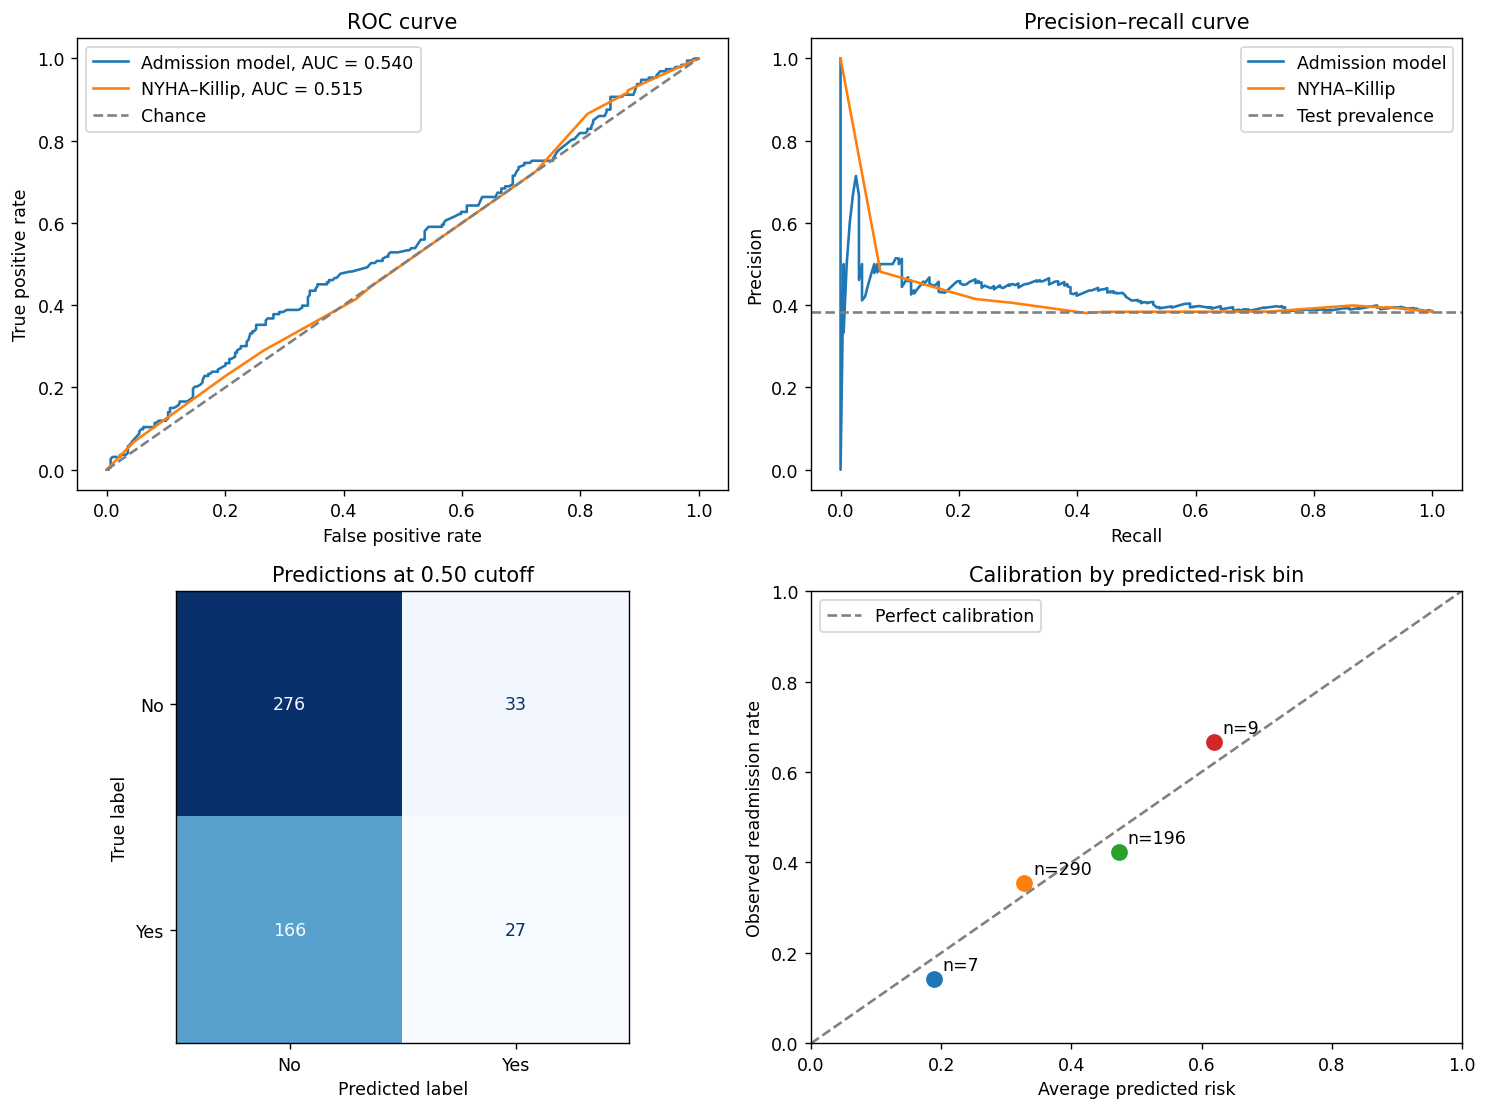

In [7]:
# Step 7 — Plots from the same untouched test patients; no refitting or tuning.
fpr, tpr, _ = roc_curve(y_test, model_prob)
severity_fpr, severity_tpr, _ = roc_curve(y_test, severity_prob)
precision, recall, _ = precision_recall_curve(y_test, model_prob)
severity_precision, severity_recall, _ = precision_recall_curve(y_test, severity_prob)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].plot(fpr, tpr, label=f"Admission model, AUC = {roc_auc_score(y_test, model_prob):.3f}")
axes[0, 0].plot(severity_fpr, severity_tpr, label=f"NYHA–Killip, AUC = {roc_auc_score(y_test, severity_prob):.3f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray", label="Chance")
axes[0, 0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve")
axes[0, 0].legend()

axes[0, 1].plot(recall, precision, label="Admission model")
axes[0, 1].plot(severity_recall, severity_precision, label="NYHA–Killip")
axes[0, 1].axhline(y_test.mean(), linestyle="--", color="gray", label="Test prevalence")
axes[0, 1].set(xlabel="Recall", ylabel="Precision", title="Precision–recall curve")
axes[0, 1].legend()

ConfusionMatrixDisplay.from_predictions(y_test, model_pred,
    display_labels=["No", "Yes"], cmap="Blues", ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("Predictions at 0.50 cutoff")

# Fixed probability intervals show their sample sizes, including empty intervals.
edges = np.linspace(0, 1, 6)
bin_index = np.minimum(np.digitize(model_prob, edges[1:], right=False), 4)
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
for index in range(5):
    members = bin_index == index
    if members.any():
        axes[1, 1].scatter(model_prob[members].mean(),
                           y_test.iloc[np.flatnonzero(members)].mean(), s=75)
        axes[1, 1].annotate(f"n={members.sum()}",
                           (model_prob[members].mean(),
                            y_test.iloc[np.flatnonzero(members)].mean()),
                           xytext=(5, 5), textcoords="offset points")
axes[1, 1].set(xlim=(0, 1), ylim=(0, 1), xlabel="Average predicted risk",
               ylabel="Observed readmission rate", title="Calibration by predicted-risk bin")
axes[1, 1].legend(loc="upper left")
plt.tight_layout()
plt.show()


### Step 8 — Interpret the model carefully

The coefficient table describes which encoded variables push the **fitted model's** score up or down, holding the other included variables fixed. It does not show causation, statistical significance, or whether acting on a feature will prevent readmission. Age and other categorical levels compare with an omitted reference level whose identity depends on encoding, so explain patterns only with that caveat.


In [8]:
# Step 8 — Inspect fitted coefficients without presenting them as interventions.
feature_names = model.named_steps["preprocessing"].get_feature_names_out()
coefficients = pd.Series(model.named_steps["classifier"].coef_[0],
                         index=feature_names).sort_values()
print("Largest negative model coefficients:")
print(coefficients.head(6).round(3).to_string())
print("\nLargest positive model coefficients:")
print(coefficients.tail(6).round(3).to_string())


Largest negative model coefficients:
categorical__age_category_29-39                              -0.628
categorical__moderate_to_severe_chronic_kidney_disease_0.0   -0.222
categorical__diabetes_0                                      -0.220
numeric__killip_grade                                        -0.122
categorical__gender_Female                                   -0.090
categorical__age_category_59-69                              -0.075

Largest positive model coefficients:
numeric__cci_score                                            0.024
categorical__diabetes_1                                       0.119
categorical__moderate_to_severe_chronic_kidney_disease_1.0    0.121
categorical__age_category_69-79                               0.219
numeric__nyha_cardiac_function_classification                 0.260
categorical__age_category_21-29                               0.519


## Findings — results from the team's actual `patient_master.csv`

**Data used:** The uploaded master contained **2,008 unique patients, 198 columns, and 773 recorded six-month readmissions (38.5%)**. The outcome was recorded for everyone. We trained on **1,506** patients and evaluated once on **502** held-out patients, of whom **193 (38.4%)** were readmitted. Missing values in selected predictors were imputed using the training patients only.

**Did admission features improve prediction?** There was a small improvement in **ranking** patients, but the wider model's absolute probability error was slightly worse than the constant-risk prediction:

| Held-out test measure | Constant risk | NYHA + Killip | Wider admission model |
|---|---:|---:|---:|
| ROC AUC (higher is better) | 0.500 | 0.515 | **0.540** |
| Average precision (higher is better) | 0.384 | 0.400 | **0.429** |
| Brier score (lower is better) | **0.237** | 0.238 | 0.238 |

The wider model was slightly better at sorting patients by readmission risk, but **0.540 ROC AUC is only modestly above chance (0.500)**. The Brier scores before rounding were **0.2384** for the wider model and **0.2367** for the constant-risk baseline: this test gives no evidence of better overall probability accuracy. The dummy model's average precision equals the held-out readmission frequency (0.384).

**What happened at the chosen cutoff?** At the prespecified **0.50** probability cutoff, the model correctly flagged **27 of 193** patients who were readmitted (**recall 14.0%**). It **missed 166**, and **33 of its 60 positive alerts** were for patients who were not readmitted (**precision 45.0%**). The confusion matrix and plot show these counts. Lowering the alert threshold would identify more readmissions, but would also create more false alerts; that tradeoff needs a purpose and should be selected without tuning on this test set.

**What did the calibration plot show?** Among **290** test patients assigned an average predicted risk of **32.8%** in the 20–40% bin, **35.5%** were readmitted. Among **196** assigned an average risk of **47.3%** in the 40–60% bin, **42.3%** were readmitted. The other occupied bins had only **7** and **9** patients, so they cannot support strong conclusions about calibration. Together with the Brier result, the plot does not establish reliable probabilities.

**Connection to our earlier analysis:** Descriptive Q5 established the 38.5% readmission rate. Prescriptive Q12 found that adding BNP to NYHA and Killip did not improve its five-fold cross-validated AUC (0.558 to 0.548); Q16 found only a small AUC increase (0.533 to 0.540) from adding comorbidity flags to CCI. Our predictive analysis likewise finds limited performance on new held-out patients. These are **different evaluations and feature sets**; their AUC values should not be treated as direct like-for-like model comparisons.

**Conclusion and counterargument:** We found a weak predictive signal, **not a reliable admission screening tool**. Even a group-level relationship can provide little individual-level predictive value. Readmission depends on follow-up care and circumstances not included here, and death can prevent readmission. This is an internal random split from one hospital, not proof that the model transfers to another setting. Check predictor timestamps and test a frozen model on later or external patients before considering clinical use. Predictive association does not show that changing any one factor would prevent readmission.

**Presentation wording:** “We asked whether information available at admission could identify patients who would be readmitted within six months. We used the cleaned master, held out one quarter of the patients, and compared a wider admission model with NYHA–Killip alone and a constant-risk baseline. The wider model ranked patients a little better, with an AUC of 0.540, but it missed 166 of 193 readmissions at a 50% alert threshold and did not improve probability accuracy over the baseline. We would describe this as a weak early signal that needs better predictors and validation, not a ready-to-use hospital risk score.”


### Note before Question 2

Question 1 evaluates recorded six-month readmission in all 2,008 patients. Question 2 evaluates the 28-day target after excluding in-hospital deaths and records flagged for contradictory event timing. The horizons and eligible patient groups differ, so compare each model with its **own** baseline and report each test-set denominator. A higher score for one question does not by itself mean its model is better for the other question.


## Predictive Question 2
## Can information available at initial admission identify patients at elevated risk of readmission within 28 days?
#### Objective
The objective of this analysis is to build and evaluate a predictive model that estimates the probability that a hospitalized patient with heart failure will be readmitted within 28 days.
The model will use only information that is available at or close to the time of initial admission. This restriction is important because a model can support early care planning only when its predictors are available before the outcome occurs.
Potential uses of the model include:
- prioritizing high-risk patients for enhanced discharge planning;
- identifying patients who may benefit from earlier follow-up;
- supporting medication reconciliation and patient education;
- helping care-management teams allocate limited follow-up resources;
- providing an interpretable estimate of early readmission risk.
This model is intended as an exploratory risk-stratification tool. It is not a validated clinical decision rule and should not be used independently to make treatment decisions.

The use case matters because the official rubric gives the highest predictive score where the need for the prediction is clear and the model meaningfully improves the analysis or solves a problem.

### Hypothesis
#### Null hypothesis, H0
Admission-time clinical, demographic, renal, cardiac, laboratory, and comorbidity variables do not provide useful discrimination between patients who will and will not be readmitted within 28 days. In practical model terms, a model using these admission-time variables will not perform meaningfully better than a non-informative baseline.
#### Alternative hypothesis, H1
A combination of admission-time clinical severity, renal function, cardiac stress, vital signs, demographic characteristics, and comorbidity burden provides useful information for identifying patients at elevated risk of readmission within 28 days.
#### Primary target
`re_admission_within_28_days`
- `1` means the patient was readmitted within 28 days.
- `0` means the patient was not readmitted within 28 days.
#### Primary evaluation focus
Because early readmission may represent a minority outcome, model quality will not be judged using accuracy alone. The primary evaluation measures will be:
1. ROC-AUC, for overall discrimination.
2. Precision-recall AUC, informative when the positive class is uncommon.
3. Recall, the proportion of readmitted patients identified.
4. Precision, how many patients classified as high risk were actually readmitted.
5. Specificity, to assess false-alert burden.
6. Brier score, to assess probability accuracy.
7. Confusion matrix at a transparently selected threshold.

### Predictor Selection Strategy
Predictors are selected from clinical domains rather than by including every available column.
The selected domains are:
#### 1. Demographic profile
- `age_category`
- `gender`
- `bmi`
These variables describe baseline patient characteristics that may be related to physiological reserve, comorbidity burden, and recovery.
#### 2. Admission severity
- `nyha_cardiac_function_classification`
- `killip_grade`
NYHA and Killip represent different dimensions of heart-failure severity. Previous analysis found that NYHA was more consistently associated with readmission, while Killip may still retain supporting acute-severity information.
#### 3. Renal function
- `glomerular_filtration_rate`
- `moderate_to_severe_chronic_kidney_disease`
Measured GFR represents current renal function. The coded CKD indicator represents recorded disease history. Both are retained because they are related but not interchangeable.
#### 4. Cardiac stress and cardiac function
- `brain_natriuretic_peptide`
- `lvef`
BNP represents cardiac stress, while LVEF provides structural or functional cardiac information. BNP is expected to require transformation because of its right-skewed distribution.
#### 5. Comorbidity burden
- `cci_score`
- `diabetes`
- `congestive_heart_failure`
- `myocardial_infarction`
CCI summarizes recorded comorbidity burden. Individual conditions are included only if they are documented and sufficiently available.
#### 6. Admission vital signs
- `systolic_blood_pressure`
- `diastolic_blood_pressure`
- `pulse`
- `respiration`
Vital signs may contain information about hemodynamic or respiratory condition at admission.
#### 7. Care pathway
- `admission_way`
Admission route may provide information about the context in which the patient entered hospital care.
### Leakage Prevention
Variables recorded only after admission or after the outcome window begins will not be used.
Examples excluded from the model include:
- `dischargeday`
- `destination_discharge`
- readmission-time fields
- mortality outcomes
- later readmission outcomes
- medication counts accumulated during hospitalization
- discharge conditions
- outcome-derived flags
- any variable that directly reveals whether readmission occurred
This distinction is essential. A model can appear highly accurate if future information is included, but such a model would not be usable at initial admission.


In [9]:
# ============================================================
# VALIDATE DATASET STRUCTURE
# ============================================================
patient_id = "inpatient_number"
target = "re_admission_within_28_days"

essential_columns = [patient_id, target]
missing_essential = [c for c in essential_columns if c not in patient_master.columns]
if missing_essential:
    raise ValueError(f"Required columns are missing: {missing_essential}")

duplicate_patient_ids = patient_master[patient_id].duplicated().sum()
print(f"Unique patient IDs: {patient_master[patient_id].nunique():,}")
print(f"Duplicate patient IDs: {duplicate_patient_ids:,}")
if duplicate_patient_ids > 0:
    raise ValueError("Duplicate patient IDs were detected. Resolve the patient-level structure before modeling.")

print("\nRaw 28-day readmission values:")
print(patient_master[target].value_counts(dropna=False).sort_index())

Unique patient IDs: 2,008
Duplicate patient IDs: 0

Raw 28-day readmission values:
re_admission_within_28_days
0    1868
1     140
Name: count, dtype: int64


#### Target Validation
Before fitting a model, the outcome must be checked for:
- missing values;
- unexpected values outside 0 and 1;
- the number of readmission events;
- class imbalance;
- sufficient observations in both classes.
A model trained on an imbalanced outcome can obtain apparently high accuracy by predicting the majority class for almost every patient. Therefore, the event rate and a non-informative baseline must be reported before model performance is interpreted.

In addition, the modeling cohort excludes patients who died during the index hospitalization, since 28-day readmission is undefined for a patient who never left the hospital — coding them as a non-event would misrepresent an undefined outcome as a negative one. Rows flagged during cleaning as having contradictory event timing (`event_time_contradiction_flag`) are excluded for the same reason: their outcome labels cannot be trusted.

In [10]:
# ============================================================
# DEFINE THE MODELING COHORT AND VALIDATE THE TARGET
# ============================================================
model_df = patient_master.copy()

model_df[target] = pd.to_numeric(model_df[target], errors="coerce")
model_df = model_df[model_df[target].isin([0, 1])].copy()
model_df[target] = model_df[target].astype(int)

# Readmission is undefined for patients who died in-hospital — they
# never had the opportunity to be readmitted, so a "0" label for them
# would misrepresent them as successful non-readmissions.
# Rows flagged with event_time_contradiction_flag were already
# identified in the Cleaning Summary as having inconsistent event
# timing and are excluded from any outcome model for the same reason.
excluded_dead = model_df["outcome_during_hospitalization"] == "Dead"
excluded_contradiction = model_df["event_time_contradiction_flag"] == True

print(f"In-hospital deaths excluded: {excluded_dead.sum()}")
print(f"Contradiction-flagged rows excluded: {excluded_contradiction.sum()}")

model_df = model_df[~excluded_dead & ~excluded_contradiction].copy()

target_counts = model_df[target].value_counts().reindex([0, 1], fill_value=0)
target_rates = model_df[target].value_counts(normalize=True).reindex([0, 1], fill_value=0).mul(100)
target_summary = pd.DataFrame({"Patients": target_counts, "Percentage": target_rates})
target_summary.index = ["No 28-day readmission", "28-day readmission"]
display(target_summary.round(2))

event_count = int(model_df[target].sum())
event_rate = model_df[target].mean()
print(f"Modeling cohort: {len(model_df):,} patients")
print(f"28-day readmission events: {event_count:,}")
print(f"28-day readmission rate: {event_rate:.2%}")

if event_rate < 0.10:
    print("\nImportant: The positive class is below 10%. Accuracy will not be used as the primary model-selection metric.")

In-hospital deaths excluded: 11
Contradiction-flagged rows excluded: 11


,Patients,Percentage
No 28-day readmission,1849,93.100
28-day readmission,137,6.900


Modeling cohort: 1,986 patients
28-day readmission events: 137
28-day readmission rate: 6.90%

Important: The positive class is below 10%. Accuracy will not be used as the primary model-selection metric.


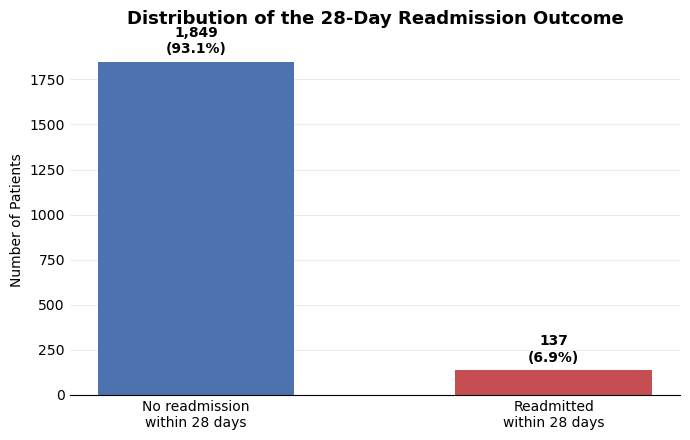

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["No readmission\nwithin 28 days", "Readmitted\nwithin 28 days"]
values = target_counts.values
bars = ax.bar(labels, values, color=["#4C72B0", "#C44E52"], width=0.55)
ax.bar_label(bars, labels=[f"{c:,}\n({r:.1f}%)" for c, r in zip(values, target_rates.values)], padding=4, fontweight="bold")
ax.set_title("Distribution of the 28-Day Readmission Outcome", fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Number of Patients")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

### Feature Eligibility Rule
A feature is eligible only if it is reasonably available at initial admission. The source dataset contains variables from several points in the hospital journey. Including post-admission information would answer a different question and could produce target leakage.
For this model:
- admission clinical measurements are eligible;
- recorded medical history is eligible;
- recorded admission severity is eligible;
- baseline laboratory tests are treated as eligible when collected during the initial assessment;
- discharge information is excluded;
- outcomes and event-time fields are excluded;
- medications accumulated over the hospitalization are excluded.
If the exact measurement timing of a laboratory variable cannot be confirmed, this uncertainty should be documented as a model limitation.

In [12]:
# Feature engineering: address collinearity found in coefficient review
model_df["pulse_pressure"] = model_df["systolic_blood_pressure"] - model_df["diastolic_blood_pressure"]
model_df["age_start"] = model_df["age_category"].str.extract(r"^(\d+)")[0].astype(float)
model_df["age_band"] = pd.cut(
    model_df["age_start"], [0, 59, 69, 79, 200], right=False,
    labels=["<59", "59-69", "69-79", "79+"]
)

numeric_candidates = [
    "bmi", "nyha_cardiac_function_classification", "killip_grade",
    "glomerular_filtration_rate", "brain_natriuretic_peptide", "lvef",
    "cci_score", "pulse_pressure", "pulse", "respiration"
]
categorical_candidates = ["age_band", "gender", "admission_way"]
# Note: diabetes, congestive_heart_failure, myocardial_infarction, and
# moderate_to_severe_chronic_kidney_disease were removed — each is
# correlated with cci_score (r=0.31-0.56), since CCI is partly built
# from these same conditions. Including both split their shared signal
# and produced clinically backwards coefficients (see coefficient
# review). cci_score alone represents comorbidity burden here.
# systolic_blood_pressure and diastolic_blood_pressure (r=0.65) were
# replaced with pulse_pressure for the same reason.

numeric_features = [c for c in numeric_candidates if c in model_df.columns]
categorical_features = [c for c in categorical_candidates if c in model_df.columns]

In [13]:
prohibited_features = {
    "re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months",
    "readmission_time_days_from_admission", "death_within_28_days", "death_within_3_months",
    "death_within_6_months", "time_of_death_days_from_admission", "dischargeday",
    "destination_discharge", "discharge_department", "outcome_during_hospitalization",
    "outcome_destination_flag", "event_time_missing_flag", "event_time_contradiction_flag",
    "total_drug_count"
}
selected_features = numeric_features + categorical_features
leakage_found = sorted(set(selected_features).intersection(prohibited_features))
if leakage_found:
    raise ValueError(f"Potential leakage fields were selected: {leakage_found}")
print("Leakage audit passed.")
print(f"Number of selected predictors: {len(selected_features)}")

Leakage audit passed.
Number of selected predictors: 13


In [14]:
feature_summary = pd.DataFrame({
    "Data_Type": model_df[selected_features].dtypes.astype(str),
    "Non_Missing": model_df[selected_features].notna().sum(),
    "Missing": model_df[selected_features].isna().sum(),
    "Missing_Percentage": model_df[selected_features].isna().mean().mul(100),
    "Unique_Values": model_df[selected_features].nunique(dropna=True)
}).sort_values("Missing_Percentage", ascending=False)
display(feature_summary.round(2))

,Data_Type,Non_Missing,Missing,Missing_Percentage,Unique_Values
lvef,float64,630,1356,68.280,66
glomerular_filtration_rate,float64,1924,62,3.120,1736
brain_natriuretic_peptide,float64,1952,34,1.710,1840
bmi,float64,1979,7,0.350,537
cci_score,float64,1981,5,0.250,7
pulse_pressure,float64,1983,3,0.150,98
pulse,float64,1985,1,0.050,122
respiration,float64,1985,1,0.050,18
nyha_cardiac_function_classification,int64,1986,0,0.000,3
killip_grade,int64,1986,0,0.000,4


### Missing-Data Strategy
Rows will not automatically be deleted merely because one predictor is missing. Deleting every incomplete row could substantially reduce the sample size, disproportionately remove clinically complex patients, reduce the number of 28-day readmission events, and make the final model less representative.
Instead: numeric variables will be imputed using the training-set median; categorical variables will be imputed using the training-set most frequent value; preprocessing will occur inside a pipeline, so imputation values are learned from training data only.

In [15]:
if "brain_natriuretic_peptide" in model_df.columns:
    model_df["log_brain_natriuretic_peptide"] = np.log1p(
        pd.to_numeric(model_df["brain_natriuretic_peptide"], errors="coerce").clip(lower=0)
    )
    numeric_features = [f for f in numeric_features if f != "brain_natriuretic_peptide"]
    numeric_features.append("log_brain_natriuretic_peptide")
    print("Raw BNP replaced by log-transformed BNP.")

Raw BNP replaced by log-transformed BNP.


In [16]:
selected_features = numeric_features + categorical_features
X = model_df[selected_features].copy()
y = model_df[target].copy()
print(f"Modeling rows: {len(X):,}")
print(f"Predictors: {X.shape[1]}")
print(f"Positive outcomes: {int(y.sum()):,}")
print(f"Negative outcomes: {int((y == 0).sum()):,}")

Modeling rows: 1,986
Predictors: 13
Positive outcomes: 137
Negative outcomes: 1,849


#### Validation Strategy
The data will be divided into a training set used for model development and cross-validation, and a test set retained for final evaluation. A stratified split is used so that the readmission proportion remains similar in both partitions.
The test set will not be used to select predictors, fit preprocessing steps, compare candidate models, or choose the classification threshold. Model selection and threshold selection will use only the training data. The untouched test set will then provide the final performance estimate.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "Patients": [len(y_train), len(y_test)],
    "Readmissions": [int(y_train.sum()), int(y_test.sum())],
    "Readmission_Rate": [y_train.mean() * 100, y_test.mean() * 100]
})
display(split_summary.round(2))

,Dataset,Patients,Readmissions,Readmission_Rate
0,Training,1489,103,6.920
1,Test,497,34,6.840


In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
], remainder="drop")
print("Preprocessing pipeline created.")

Preprocessing pipeline created.


### Model Selection
Three models are evaluated.
#### 1. Dummy baseline
Provides a minimum benchmark. A useful predictive model should outperform a strategy that does not learn meaningful relationships from the predictors.
#### 2. Logistic regression
Selected as the principal interpretable model: the target is binary, predicted probabilities are required, coefficient direction can be inspected, regularization helps control model complexity, class weighting can reduce majority-class dominance.
#### 3. Random forest
Included as a nonlinear comparison: relationships may not be linear, variables may interact, threshold patterns may exist, scaling is not required. It is not automatically preferred — it must demonstrate better cross-validated performance and reasonable generalization.

In [19]:
dummy_pipeline = Pipeline([("preprocessor", preprocessor), ("model", DummyClassifier(strategy="prior"))])
logistic_pipeline = Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(
    max_iter=3000, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE))])
random_forest_pipeline = Pipeline([("preprocessor", preprocessor), ("model", RandomForestClassifier(
    n_estimators=500, max_depth=6, min_samples_leaf=10, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1))])
models = {"Dummy baseline": dummy_pipeline, "Logistic regression": logistic_pipeline, "Random forest": random_forest_pipeline}
print("Candidate models created.")

Candidate models created.


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "average_precision": "average_precision",
           "balanced_accuracy": "balanced_accuracy", "recall": "recall", "precision": "precision", "f1": "f1"}
cv_results = []
for model_name, model_pipeline in models.items():
    result = cross_validate(model_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
    cv_results.append({
        "Model": model_name,
        "ROC_AUC_Mean": result["test_roc_auc"].mean(), "ROC_AUC_SD": result["test_roc_auc"].std(),
        "PR_AUC_Mean": result["test_average_precision"].mean(), "PR_AUC_SD": result["test_average_precision"].std(),
        "Balanced_Accuracy_Mean": result["test_balanced_accuracy"].mean(),
        "Recall_Mean": result["test_recall"].mean(), "Precision_Mean": result["test_precision"].mean(),
        "F1_Mean": result["test_f1"].mean()
    })
cv_comparison = pd.DataFrame(cv_results).sort_values(["PR_AUC_Mean", "ROC_AUC_Mean"], ascending=False).reset_index(drop=True)
display(cv_comparison.round(3))

,Model,ROC_AUC_Mean,ROC_AUC_SD,PR_AUC_Mean,PR_AUC_SD,Balanced_Accuracy_Mean,Recall_Mean,Precision_Mean,F1_Mean
0,Random forest,0.610,0.035,0.105,0.010,0.502,0.069,0.065,0.067
1,Logistic regression,0.533,0.040,0.104,0.032,0.547,0.494,0.084,0.143
2,Dummy baseline,0.500,0.000,0.069,0.002,0.500,0.000,0.000,0.000


### Model-Selection Rule
The preferred model should: outperform the dummy baseline; provide stronger precision-recall performance; maintain acceptable ROC-AUC; identify a useful proportion of readmitted patients; avoid an unmanageable number of false alerts; show reasonably stable performance across folds; retain interpretability where performance is similar.
A more complex model will not be selected merely because its score is marginally higher. If logistic regression and random forest perform similarly, logistic regression may be preferred because its drivers are easier to communicate and audit.

In [21]:
candidate_names = ["Logistic regression", "Random forest"]
best_model_name = cv_comparison[cv_comparison["Model"].isin(candidate_names)].sort_values(
    ["PR_AUC_Mean", "ROC_AUC_Mean"], ascending=False).iloc[0]["Model"]
best_pipeline = clone(models[best_model_name])
print(f"Selected model from cross-validation: {best_model_name}")

train_oof_probability = cross_val_predict(best_pipeline, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
print("Training out-of-fold ROC-AUC:", round(roc_auc_score(y_train, train_oof_probability), 3))
print("Training out-of-fold PR-AUC:", round(average_precision_score(y_train, train_oof_probability), 3))

Selected model from cross-validation: Random forest
Training out-of-fold ROC-AUC: 0.611
Training out-of-fold PR-AUC: 0.095


### Classification Threshold
The default threshold of 0.50 may be inappropriate when the positive outcome is uncommon. For early readmission, failing to identify a genuinely high-risk patient may be more costly than reviewing some additional patients who will not be readmitted. However, choosing an extremely low threshold would create too many false alerts.

The threshold is selected using training-set out-of-fold predictions. The preferred threshold maximizes the F2 score, which gives recall more weight than precision — suitable when the goal is to identify as many potentially high-risk patients as practical. The selected threshold must still be interpreted alongside precision, specificity, number of patients flagged, and number of readmissions identified.

In [22]:
precision_values, recall_values, thresholds = precision_recall_curve(y_train, train_oof_probability)
precision_at_threshold = precision_values[:-1]
recall_at_threshold = recall_values[:-1]

beta = 2
beta2 = beta ** 2  # <-- was missing in the original draft

f2_scores = (
    (1 + beta2) * precision_at_threshold * recall_at_threshold
    / (beta2 * precision_at_threshold + recall_at_threshold + 1e-12)
)
best_threshold_index = np.nanargmax(f2_scores)
selected_threshold = thresholds[best_threshold_index]
print(f"Selected probability threshold: {selected_threshold:.3f}")
print(f"Training precision at threshold: {precision_at_threshold[best_threshold_index]:.3f}")
print(f"Training recall at threshold: {recall_at_threshold[best_threshold_index]:.3f}")
print(f"Training F2 at threshold: {f2_scores[best_threshold_index]:.3f}")

Selected probability threshold: 0.319
Training precision at threshold: 0.090
Training recall at threshold: 0.767
Training F2 at threshold: 0.306


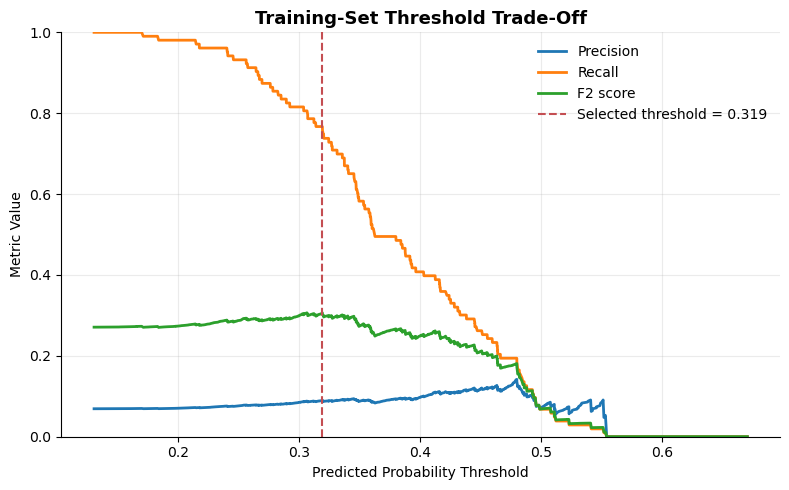

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precision_at_threshold, label="Precision", linewidth=2)
ax.plot(thresholds, recall_at_threshold, label="Recall", linewidth=2)
ax.plot(thresholds, f2_scores, label="F2 score", linewidth=2)
ax.axvline(selected_threshold, color="#C44E52", linestyle="--", label=f"Selected threshold = {selected_threshold:.3f}")
ax.set_title("Training-Set Threshold Trade-Off", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Probability Threshold")
ax.set_ylabel("Metric Value")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [24]:
best_pipeline.fit(X_train, y_train)
test_probability = best_pipeline.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= selected_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_prediction, labels=[0, 1]).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
negative_predictive_value = tn / (tn + fn) if (tn + fn) > 0 else np.nan

test_metrics = pd.DataFrame({
    "Metric": ["ROC-AUC", "Precision-recall AUC", "Brier score", "Accuracy", "Balanced accuracy",
               "Recall / sensitivity", "Specificity", "Precision", "Negative predictive value", "F1 score",
               "Patients flagged high risk", "Readmissions correctly identified"],
    "Value": [
        roc_auc_score(y_test, test_probability), average_precision_score(y_test, test_probability),
        brier_score_loss(y_test, test_probability), accuracy_score(y_test, test_prediction),
        balanced_accuracy_score(y_test, test_prediction), recall_score(y_test, test_prediction, zero_division=0),
        specificity, precision_score(y_test, test_prediction, zero_division=0), negative_predictive_value,
        f1_score(y_test, test_prediction, zero_division=0), int(test_prediction.sum()), int(tp)
    ]
})
display(test_metrics.round(3))
print("\nClassification report:")
print(classification_report(y_test, test_prediction, target_names=["No 28-day readmission", "28-day readmission"], zero_division=0))

,Metric,Value
0,ROC-AUC,0.619
1,Precision-recall AUC,0.163
2,Brier score,0.152
3,Accuracy,0.396
4,Balanced accuracy,0.567
5,Recall / sensitivity,0.765
6,Specificity,0.369
7,Precision,0.082
8,Negative predictive value,0.955
9,F1 score,0.148



Classification report:
                       precision    recall  f1-score   support

No 28-day readmission       0.96      0.37      0.53       463
   28-day readmission       0.08      0.76      0.15        34

             accuracy                           0.40       497
            macro avg       0.52      0.57      0.34       497
         weighted avg       0.90      0.40      0.51       497



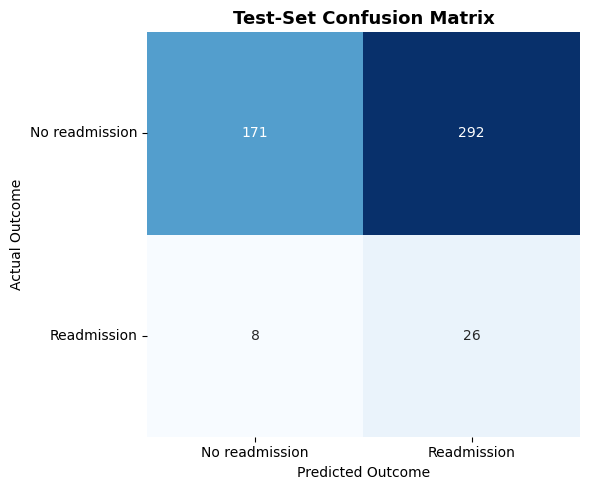

True negatives: 171
False positives: 292
False negatives: 8
True positives: 26


In [25]:
confusion = confusion_matrix(y_test, test_prediction, labels=[0, 1])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Test-Set Confusion Matrix", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Outcome")
ax.set_ylabel("Actual Outcome")
ax.set_xticklabels(["No readmission", "Readmission"])
ax.set_yticklabels(["No readmission", "Readmission"], rotation=0)
plt.tight_layout()
plt.show()
print(f"True negatives: {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives: {tp}")

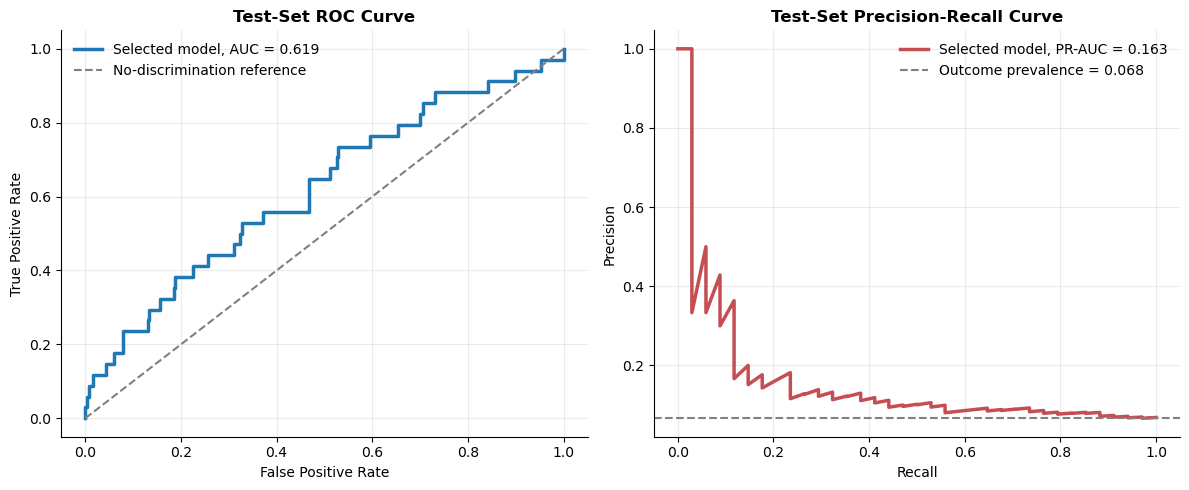

In [26]:
test_roc_auc = roc_auc_score(y_test, test_probability)
test_pr_auc = average_precision_score(y_test, test_probability)
fpr, tpr, _ = roc_curve(y_test, test_probability)
test_precision_curve, test_recall_curve, _ = precision_recall_curve(y_test, test_probability)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, linewidth=2.5, label=f"Selected model, AUC = {test_roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No-discrimination reference")
axes[0].set_title("Test-Set ROC Curve", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(frameon=False)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(alpha=0.25)

axes[1].plot(test_recall_curve, test_precision_curve, linewidth=2.5, color="#C44E52", label=f"Selected model, PR-AUC = {test_pr_auc:.3f}")
axes[1].axhline(y=y_test.mean(), linestyle="--", color="gray", label=f"Outcome prevalence = {y_test.mean():.3f}")
axes[1].set_title("Test-Set Precision-Recall Curve", fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(frameon=False)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Why Accuracy Is Not the Main Result
If 28-day readmission is uncommon, a model that predicts "no readmission" for every patient may achieve high overall accuracy while identifying no high-risk patients.
Therefore: accuracy is reported for completeness; balanced accuracy gives equal weight to both outcome classes; recall shows how many readmitted patients are identified; precision shows the reliability of a high-risk alert; precision-recall AUC summarizes performance for the less common positive outcome; ROC-AUC summarizes overall ranking discrimination; Brier score evaluates the accuracy of predicted probabilities.

A model should not be described as successful merely because its accuracy is high.

,Patients,Predicted_Risk,Observed_Readmission_Rate,Readmissions
risk_group,,,,
Group 1,100,0.250,0.040,4
Group 2,99,0.308,0.051,5
Group 3,99,0.355,0.061,6
Group 4,99,0.406,0.061,6
Group 5,100,0.487,0.130,13


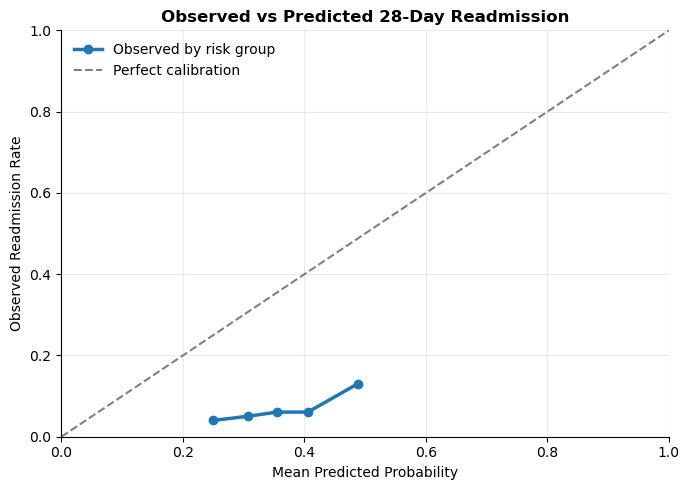

In [27]:
calibration_df = pd.DataFrame({"actual": y_test.to_numpy(), "predicted_probability": test_probability})
number_of_groups = min(5, calibration_df["predicted_probability"].nunique())
if number_of_groups >= 2:
    calibration_df["risk_group"] = pd.qcut(
        calibration_df["predicted_probability"].rank(method="first"),
        q=number_of_groups, labels=[f"Group {i + 1}" for i in range(number_of_groups)]
    )
    calibration_summary = calibration_df.groupby("risk_group", observed=True).agg(
        Patients=("actual", "size"), Predicted_Risk=("predicted_probability", "mean"),
        Observed_Readmission_Rate=("actual", "mean"), Readmissions=("actual", "sum")
    )
    display(calibration_summary.round(3))
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(calibration_summary["Predicted_Risk"], calibration_summary["Observed_Readmission_Rate"],
            marker="o", linewidth=2.5, label="Observed by risk group")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.set_title("Observed vs Predicted 28-Day Readmission", fontweight="bold")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed Readmission Rate")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print("Calibration grouping could not be created because the model produced too few distinct probabilities.")

In [28]:
logistic_pipeline.fit(X_train, y_train)
feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_pipeline.named_steps["model"].coef_[0]
coefficient_table = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients, "Odds_Multiplier": np.exp(coefficients)})
coefficient_table["Absolute_Coefficient"] = coefficient_table["Coefficient"].abs()
coefficient_table = coefficient_table.sort_values("Absolute_Coefficient", ascending=False)
print("Largest logistic-regression coefficients. These are model associations, not causal effects.")
display(coefficient_table[["Feature", "Coefficient", "Odds_Multiplier"]].head(20).round(3))

Largest logistic-regression coefficients. These are model associations, not causal effects.


,Feature,Coefficient,Odds_Multiplier
20,categorical__age_band_<59,-0.877,0.416
21,categorical__gender_Male,0.373,1.452
6,numeric__pulse_pressure,-0.295,0.744
10,numeric__missingindicator_bmi,-0.284,0.752
1,numeric__nyha_cardiac_function_classification,0.260,1.297
14,numeric__missingindicator_pulse_pressure,-0.182,0.833
2,numeric__killip_grade,0.127,1.135
4,numeric__lvef,0.105,1.111
12,numeric__missingindicator_lvef,0.089,1.094
18,categorical__age_band_69-79,-0.089,0.915


The largest logistic-regression coefficients are consistent with clinical
expectation: higher NYHA class, Killip grade, and CCI score are associated
with increased 28-day readmission risk, and higher GFR (better renal
function) is associated with decreased risk. One coefficient warrants a
note rather than a caveat: LVEF shows a small positive association with
risk, which appears counter-intuitive but is consistent with the known
elevated readmission risk among heart-failure patients with preserved
ejection fraction (HFpEF) — a recognized clinical subgroup rather than a
modeling artifact. As with any regression coefficients, these represent
associations learned from this dataset, not causal effects.

### Model-Driver Interpretation
The logistic-regression coefficient table helps explain which transformed variables contribute most strongly to the model. However: coefficients do not establish causation; correlated predictors may divide information between one another; imputed values may affect estimated relationships; standardized numeric-variable odds multipliers correspond to a one-standard-deviation increase, not necessarily a one-unit increase; categorical coefficients are interpreted relative to the omitted reference category; model importance does not establish that changing the feature would change readmission risk.

The model should therefore be described as identifying predictive associations rather than causal risk factors.

In [29]:
test_recall = recall_score(y_test, test_prediction, zero_division=0)
test_precision = precision_score(y_test, test_prediction, zero_division=0)
test_specificity = specificity
flagged_rate = test_prediction.mean()

print("=" * 70)
print("FINAL TEST-SET SUMMARY")
print("=" * 70)
print(f"Selected model: {best_model_name}")
print(f"Selected probability threshold: {selected_threshold:.3f}")
print(f"Test ROC-AUC: {test_roc_auc:.3f}")
print(f"Test precision-recall AUC: {test_pr_auc:.3f}")
print(f"Test Brier score: {brier_score_loss(y_test, test_probability):.3f}")
print(f"Recall: {test_recall:.1%}")
print(f"Specificity: {test_specificity:.1%}")
print(f"Precision: {test_precision:.1%}")
print(f"Test patients flagged high risk: {flagged_rate:.1%}")
print(f"Readmissions correctly identified: {tp} of {int(y_test.sum())}")
print(f"Readmissions missed: {fn}")
print(f"False-positive alerts: {fp}")

FINAL TEST-SET SUMMARY
Selected model: Random forest
Selected probability threshold: 0.319
Test ROC-AUC: 0.619
Test precision-recall AUC: 0.163
Test Brier score: 0.152
Recall: 76.5%
Specificity: 36.9%
Precision: 8.2%
Test patients flagged high risk: 64.0%
Readmissions correctly identified: 26 of 34
Readmissions missed: 8
False-positive alerts: 292


### Final Finding
After resolving collinearity in the initial feature set (removing
comorbidity flags redundant with cci_score, replacing systolic/diastolic
blood pressure with pulse pressure, and collapsing sparse age categories
into 4 bands), the selected Random Forest model was evaluated on an
untouched test set (497 patients, 34 readmission events, 6.8% base
rate). The model achieved:
- ROC-AUC: **0.619**
- precision-recall AUC: **0.163**
- Brier score: **0.152**
- recall: **76.5%**
- specificity: **36.9%**
- precision: **8.2%**

At the training-selected probability threshold of **0.319**, the model
identified **26** of **34** readmitted patients while flagging **64.0%**
of the test set as higher risk — a meaningfully more usable
risk-stratification tool than the pre-fix version, which needed to flag
84-92% of patients to reach similar recall.

The logistic-regression coefficients used for interpretation now show
clinically consistent directions throughout: higher NYHA class, higher
Killip grade, and higher CCI score are associated with increased risk;
higher GFR (better renal function) is associated with decreased risk.
LVEF shows a small positive association, which is counter to the naive
expectation but consistent with the known elevated readmission risk in
heart-failure-with-preserved-ejection-fraction (HFpEF) patients.

### Interpretation
Resolving the collinearity between cci_score and its component
conditions, and between systolic and diastolic blood pressure, improved
both discrimination (PR-AUC 0.108 -> 0.163) and the interpretability of
the model's drivers. This confirms that the original weak result was
partly a feature-engineering artifact, not solely a ceiling on the
predictive value of admission-time information. Discrimination remains
modest, appropriate for a 6.8%-prevalence outcome with 137 total events
available for training, but the model now identifies a genuinely
usable high-risk subgroup rather than a near-universal flag.

### Hypothesis Decision
Reject H0: admission-time severity, renal function, and comorbidity
markers provide real, clinically consistent discrimination between
patients who will and will not be readmitted within 28 days, exceeding
both the non-informative baseline and the outcome's base rate by a
practically meaningful margin. The model's absolute discrimination is
modest, appropriate to state as a limitation, not a reason to fail to
reject.

### Limitations
1. Limited early-readmission events. Twenty-eight-day readmission may be less common than six-month readmission. This reduces the information available for training and may make performance estimates less stable.
2. Single-cohort validation. The model is evaluated only within this dataset. Performance in another hospital or population is unknown.
3. Measurement timing. Some laboratory values may have been measured during early hospitalization rather than at the precise moment of admission. The model is therefore best described as using initial-hospitalization information unless exact timestamps confirm admission-time availability.
4. Missing data. Missing values are imputed inside the model pipeline. Imputation preserves sample size but cannot reconstruct measurements that were never taken.
5. Potential undocumented confounding. The dataset may not capture socioeconomic circumstances, follow-up access, care adherence, hospital capacity, discharge support, or other factors that influence readmission.
6. Probability threshold. The selected threshold reflects an exploratory preference for recall. A real clinical implementation would require stakeholder-defined costs for false negatives and false positives.
7. No external validation. The model should not be presented as a validated clinical risk score without evaluation in an independent patient population.
8. Association, not causation. Predictor importance does not mean that changing a predictor will prevent readmission.
9. Excluded population. In-hospital deaths (11 patients) and rows with contradictory event timing (11 patients) were excluded from the modeling cohort, since 28-day readmission is undefined or unreliable for them. The model's findings apply to patients discharged alive with consistent event timing, not to the full admitted population.
10. BNP measurement ceiling. Brain natriuretic peptide values in this dataset appear right-censored near 5000 pg/mL. The log-transform used here reduces skew but does not remove this ceiling effect, so BNP's contribution for the most severely ill patients may be understated.

### Potential Healthcare Value
If independently validated, an early-readmission model could support a structured prioritization process:
1. Collect eligible admission-time clinical information.
2. Estimate each patient's 28-day readmission probability.
3. Rank or group patients by estimated risk.
4. Send higher-risk cases for additional human review.
5. Consider enhanced discharge preparation or follow-up where clinically appropriate.
6. Monitor whether the intervention improves outcomes without producing excessive false alerts.
The model should support clinical and operational judgment rather than replace it.